5350 Thesis in Economics

Andres Cruz 25199 & Klara Holmer 25037 

Code for Gymnasieskola - Upper Secondary School 

In [18]:
# Importing Libraries
import numpy as np 
import pandas as pd 
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

Gymnasieskola I - Avgångselever, nationella program läsår 2014/15 till 2023/24 

"Uppgifterna avser betyg utfärdade under det valda läsåret."

- Excel filerna är ordnade efter vårterminens år
- Vi fördröjer varje excel fil med två år, eftersom vi är intresserade av första års resultaten av det avgående studenter 
- Med denna fördröjning så blir det läsår 2012/13 till 2021/22

In [19]:
# Step 1 - Creating DataFrame_I

# --- Specify which program (i.e., which sheet_name) to read ---
program = "Högskoleförberedande program" 

# Printing program choice
print(f"Your choice was {program}")


# Högskoleförberedande program
# Ekonomiprogrammet, Samhällsvetenskapsprogrammet, Estetiska programmet, och Humanistiska programmet
# Naturvetenskapsprogrammet och Teknikprogrammet

Your choice was Högskoleförberedande program


In [20]:
# Step 1 - Creating DataFrame_I

# Define the folder path
path = r'/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Raw Data/Skolverket Data/gymnasieskola_I'

# Get all Excel files in the folder
all_files = glob.glob(os.path.join(path, "*.xlsx"))

# Sort the files (ascending by default)
all_files.sort()

# Predefined list of ACADEMIC_YEAR (ensure this list matches the number of files and in the right order of how python reads the folder (ascending or descending))

# Excel files are for the cohort finishing upper secondary school
# We are mainly interested in average scores from their first year at upper secondary school, therefore the DataSets need to be lagged by two years
# With the lag the year ranges from 2014/15 to 2021/22, which is manually done below
ACADEMIC_YEAR = ['2014/15', '2015/16', '2016/17','2017/18', '2018/19', '2019/20', '2020/21', '2021/22']

# Defining a function
def read_excel_files(sheet_name):

    """""
    This function reads each excel file from the specified path and sheet, modifies the dataframes, and then creates a concatenated DataFrame

    Parameters:
    - sheet_name: specify which upper secondary program to read. This is done in the chunk above
    """""

    # Create an empty list to store DataFrames
    li = []
    
    # A for loop
    for i, filename in enumerate(all_files):
        
        if i == 0:
            # For the first file, read without skipping rows to extract the header row (index 8), Pandas DataFrame positioning
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Extract column names from row index 8
            column_names = temp_df.iloc[8].tolist()
            # Now read the data, skipping the first 9 rows from the excel file
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=9)
            # Assign the extracted column names
            df.columns = column_names
        else:
            # For subsequent files, read without skipping rows to locate the matching row
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Locate the row number where the column names match
            column_names_row = temp_df.apply(lambda row: row.tolist() == column_names, axis=1).idxmax()
            # Read the data, skipping rows up to the matching row
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=column_names_row + 1)
            # Assign the extracted column names
            df.columns = column_names

        # Add the "academic_year" column using the predefined years list
        df['academic_year'] = ACADEMIC_YEAR[i] 

        # Add the "educational_stage" column with the fixed value 'gymnasieskola'
        df["educational_stage"] = 'gymnasieskola'

        # Append the DataFrame to the list
        li.append(df)
    
    return pd.concat(li, ignore_index=True)

# Applying the function, with specified program
DataFrame_I = read_excel_files(program)

print(DataFrame_I)

                               Skola  Skol-enhetskod  Skolkommun  Kommun-kod  \
0        Alströmergymnasiet sektor 1        74776778    Alingsås        1489   
1        Alströmergymnasiet sektor 2        18345915    Alingsås        1489   
2        Alströmergymnasiet sektor 3        68229719    Alingsås        1489   
3        Alströmergymnasiet sektor 4        61004230    Alingsås        1489   
4                      Vasagymnasiet        71262305      Arboga        1984   
...                              ...             ...         ...         ...   
6201        Östersunds Gymnasieskola        47559319   Östersund        2380   
6202            Österåkers gymnasium        20752831   Österåker         117   
6203  Bruksgymnasiet/Gimo utb.centr.        51023367   Östhammar         382   
6204             Vattenfallgymnasiet        34739511   Östhammar         382   
6205              Gränsälvsgymnasiet        52690153  Övertorneå        2518   

     Typ av huvudman                   

In [21]:
# Step 2  - Changing column names and dropping columns that will not be used

# Define a list of new column names in the correct order
new_names = [
    'school_name',                                               # Column 1: from 'Skola'
    'school_ID',                                                 # Column 2: from 'Skol-enhetskod'
    'school_municipality',                                       # Column 3: from 'Skolkommun'
    'municipality_ID',                                           # Column 4: from 'Kommun-kod'
    'type_of_ownership',                                         # Column 5: from 'Typ av huvudman'
    'owner',                                                     # Column 6: from 'Huvudman'
    'owner_orgnr',                                               # Column 7: from 'Huvudman orgnr'
    'graduating_students',                                       # Column 8: from 'Totalt antal' 
    'share_with_degree',                                         # Column 9: from 'Andel (%) med examen'
    'share_with_study_certificate',                              # Column 10: from 'Andel (%) med studiebevis'
    'share_with_basic_eligibility',                              # Column 11: from 'Andel (%) med grundl. behörighet'
    'share_with_extended_program',                               # Column 12: from 'Andel (%) med utökat prog.'
    'graduates_average_grade_points',                            # Column 13: from 'GBP för elever med examen eller studiebevis'
    'AGP_students_with_study_certificate',                       # Column 14: from 'GBP för elever med examen'
    'share_students_A_E_eng',                                    # Column 15: from 'Eng 5'
    'share_students_A_E_history',                                # Column 16: from 'Historia 1'
    'share_students_A_E_physical_education',                     # Column 17: from 'Idrott 1'
    'share_students_A_E_ma',                                     # Column 18: from 'Ma 1'
    'share_students_A_E_natural_sciences',                       # Column 19: from 'Na 1'
    'share_students_A_E_religion',                               # Column 20: from 'Re 1'
    'share_students_A_E_social_studies',                         # Column 21: from 'Sam 1'
    'share_students_A_E_sv',                                     # Column 22: from 'Sv 1'
    'share_students_A_E_swedish_as_second_language',             # Column 23: from 'Sv andraspr. 1'
    'share_students_A_E_gymnarb',                                # Column 24: from 'Gymnarb.'
    'academic_year',                                             # Column 25: from 'läsår'
    'educational_stage'                                          # Column 26: from 'skolform'
    ]
    
# Assign the new column names based on their position
DataFrame_I.columns = new_names

# Define the list of columns to drop
columns_to_drop = [
    'school_name', 'owner', 'owner_orgnr', 'share_with_degree', 'share_with_study_certificate', 
    'share_with_basic_eligibility', 'share_with_extended_program', 
    'AGP_students_with_study_certificate', 'share_students_A_E_history', 'share_students_A_E_physical_education', 
    'share_students_A_E_natural_sciences', 'share_students_A_E_religion', 'share_students_A_E_social_studies', 
    'share_students_A_E_swedish_as_second_language', 'share_students_A_E_gymnarb'
    ]

# Drop the specified columns
DataFrame_I.drop(columns=columns_to_drop, axis=1, inplace=True)

DataFrame_I

,school_ID,school_municipality,municipality_ID,type_of_ownership,graduating_students,graduates_average_grade_points,share_students_A_E_eng,share_students_A_E_ma,share_students_A_E_sv,academic_year,educational_stage
0,74776778,Alingsås,1489,Kommunal,44,14.7,97.7,100,100,2014/15,gymnasieskola
1,18345915,Alingsås,1489,Kommunal,41,15.2,100,100,100,2014/15,gymnasieskola
2,68229719,Alingsås,1489,Kommunal,45,14.8,100,100,100,2014/15,gymnasieskola
3,61004230,Alingsås,1489,Kommunal,44,16.5,100,97.7,100,2014/15,gymnasieskola
4,71262305,Arboga,1984,Kommunal,63,15.5,100,100,100,2014/15,gymnasieskola
...,...,...,...,...,...,...,...,...,...,...,...
6201,47559319,Östersund,2380,Enskild,34,12.8,100,88.2,100,2021/22,gymnasieskola
6202,20752831,Österåker,117,Kommunal,172,13.5,98.8,96.5,98.2,2021/22,gymnasieskola
6203,51023367,Östhammar,382,Kommunal,55,14.6,100,100,100,2021/22,gymnasieskola
6204,34739511,Östhammar,382,Enskild,23,14.5,100,100,100,2021/22,gymnasieskola


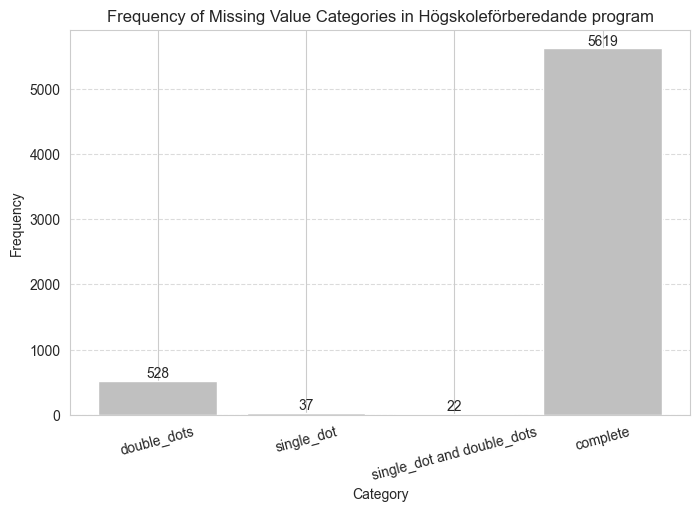

/var/folders/dk/hpy2mtkd7sq6_2c3125100b80000gn/T/ipykernel_14714/1811510187.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_missing['academic_year_numeric'] = df_missing['academic_year'].str[-2:].astype(int)
/var/folders/dk/hpy2mtkd7sq6_2c3125100b80000gn/T/ipykernel_14714/1811510187.py:95: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  bottom[i] + height / 2,


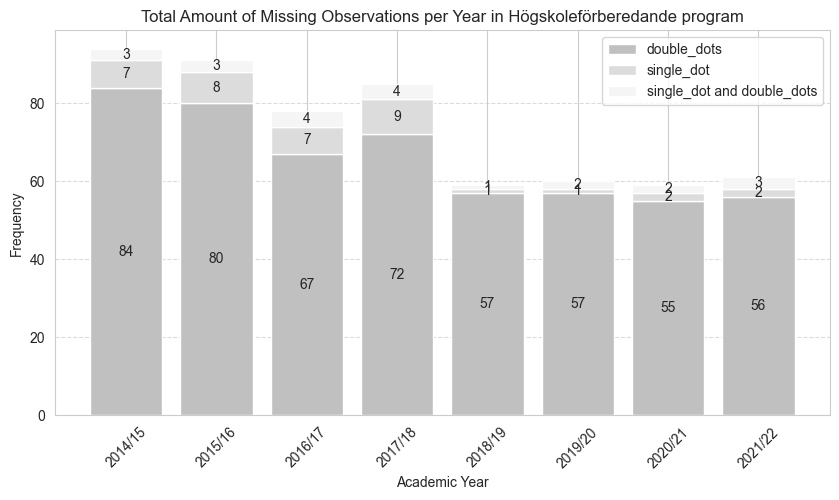

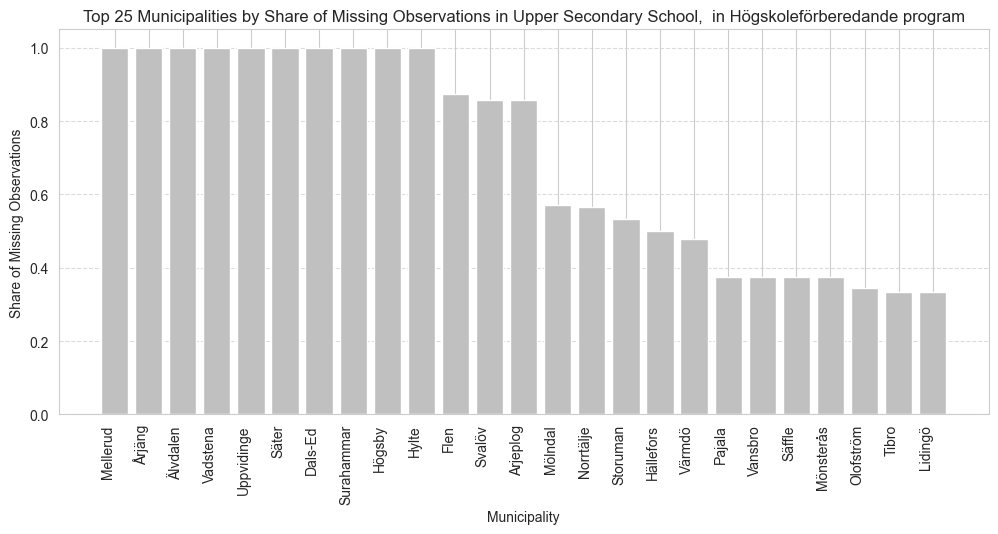

/var/folders/dk/hpy2mtkd7sq6_2c3125100b80000gn/T/ipykernel_14714/1811510187.py:149: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = DataFrame_I.replace(['.', '..'], np.nan)


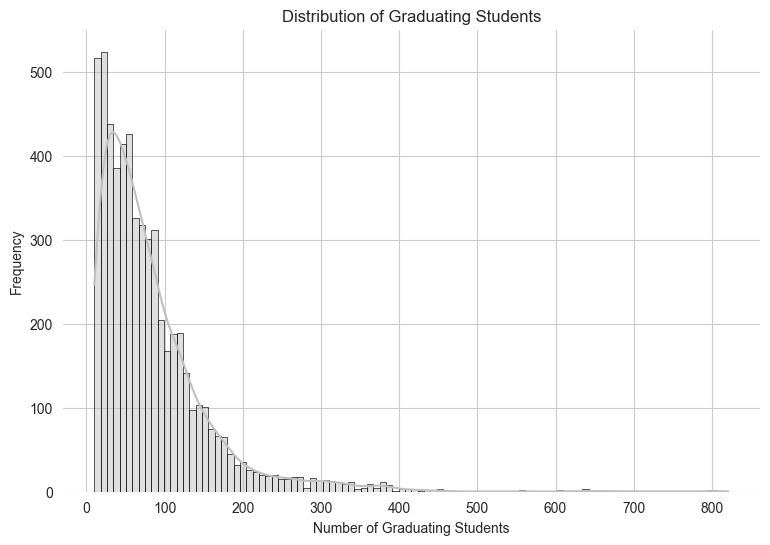

      school_ID school_municipality  municipality_ID type_of_ownership  \
0      74776778            Alingsås             1489          Kommunal   
1      18345915            Alingsås             1489          Kommunal   
2      68229719            Alingsås             1489          Kommunal   
3      61004230            Alingsås             1489          Kommunal   
4      71262305              Arboga             1984          Kommunal   
...         ...                 ...              ...               ...   
6201   47559319           Östersund             2380           Enskild   
6202   20752831           Österåker              117          Kommunal   
6203   51023367           Östhammar              382          Kommunal   
6204   34739511           Östhammar              382           Enskild   
6205   52690153          Övertorneå             2518          Kommunal   

     graduating_students graduates_average_grade_points  \
0                     44                           1

In [22]:
# Step 2 - A Side Analysis - Types of Missing Data

"""
Om resultatuppgiften baseras på färre än 10 elever, dubbelprickas den. 
Då visas två prickar (..)  istället för utfall. 
Om data saknas visas en prick (.) istället för utfall.
"""

# --- Plot 1: Frequency of Missing Value Categories ---

# Function to classify rows based on presence of '.' and '..'
def classify_missing_rows(row):
    contains_single_dot = (row == '.').any()
    contains_double_dot = (row == '..').any()

    if contains_single_dot and contains_double_dot:
        return "single_dot and double_dots"
    elif contains_double_dot:
        return "double_dots"
    elif contains_single_dot:
        return "single_dot"
    else:
        return "complete"

# Apply classification to the DataFrame
DataFrame_I["missing_data"] = DataFrame_I.apply(classify_missing_rows, axis=1)

# Define all possible category labels to ensure they appear in the plot
all_categories = ["double_dots", "single_dot", "single_dot and double_dots", "complete"]

# Count occurrences of each category and reindex to include all categories
category_counts = DataFrame_I['missing_data'].value_counts().reindex(all_categories, fill_value=0)

# Plot the frequency of each category
plt.figure(figsize=(8, 5))
bars = plt.bar(category_counts.index, category_counts.values, color='silver')

# Add count annotations to each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom')

# Formatting
plt.xlabel("Category")
plt.ylabel("Frequency")
plt.title(f"Frequency of Missing Value Categories in {program}")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()

# --- Plot 2: Total Amount of Missing Observations per Year ---

# Function to filter rows that contain missing indicators
def filter_missing_rows(df): 
    return df[df.isin(['double_dots', 'single_dot', 'single_dot and double_dots']).any(axis=1)]

# Apply filtering to obtain only rows with missing data
df_missing = filter_missing_rows(DataFrame_I)

# Optionally, extract a numeric value from the academic_year column for sorting purposes.
# Here we assume academic_year is in a "YYYY/YY" format.
df_missing['academic_year_numeric'] = df_missing['academic_year'].str[-2:].astype(int)

# Group by academic year and missing data category, then count occurrences.
grouped = df_missing.groupby(['academic_year', 'missing_data']).size().unstack(fill_value=0)
grouped = grouped.reindex(sorted(df_missing['academic_year'].unique()))

# Define the order of categories for stacking.
categories_order = ['double_dots', 'single_dot', 'single_dot and double_dots']

# Define colors for each category.
colors = {
    'double_dots': 'silver',
    'single_dot': 'gainsboro',
    'single_dot and double_dots': 'whitesmoke'
}

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(grouped))  # Initialize bottom for stacking

# Loop over each category, plotting its segment and adding count annotations.
for cat in categories_order:
    values = grouped.get(cat, pd.Series(0, index=grouped.index))
    bars = ax.bar(grouped.index, values, bottom=bottom, label=cat, color=colors[cat])
    
    # Add text labels to each segment
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[i] + height / 2,
                str(int(height)),
                ha='center',
                va='center',
                fontsize=10
            )
    bottom += values  # Update bottom for next category

# Formatting the plot
ax.set_xlabel("Academic Year")
ax.set_ylabel("Frequency")
ax.set_title(f'Total Amount of Missing Observations per Year in {program}')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# Display the plot
plt.show()

# --- Plot 3: Frequency of Missing Observations per Municipality ---

# Calculate missing counts per municipality using the "missing_data" column
# (Rows with missing data are those where missing_data is not "complete")
missing_counts = DataFrame_I.loc[DataFrame_I['missing_data'] != 'complete', 'school_municipality'].value_counts()

# Calculate total counts per municipality from the full DataFrame
total_counts = DataFrame_I['school_municipality'].value_counts()

# Compute the share of missing observations per municipality
share_missing = missing_counts / total_counts

# Sort the share values in descending order and select the top 25 municipalities
top25_share_missing = share_missing.sort_values(ascending=False).head(25)

# Plot the share of missing observations per municipality for the top 25
plt.figure(figsize=(12, 5))
plt.bar(top25_share_missing.index, top25_share_missing.values, color='silver')

# Formatting the plot
plt.xlabel("Municipality")
plt.ylabel("Share of Missing Observations")
plt.title(f"Top 25 Municipalities by Share of Missing Observations in Upper Secondary School,  in {program}")
plt.xticks(rotation=90, ha="right")  # Rotate labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

# Dropping column created for plot 1
DataFrame_I.drop('missing_data', axis = 1, inplace=True )

# --- Plot 4: Distribution of Graduating Students ---

# Replacing . and .. with np.nan
df = DataFrame_I.replace(['.', '..'], np.nan)

# Set Seaborn theme for a clean look
sns.set_style("whitegrid")  

# Create the figure and axis
plt.figure(figsize=(9, 6))

# Histogram with KDE (density plot)
sns.histplot(df['graduating_students'], bins=100, kde=True, color="silver", edgecolor="black", alpha=0.5)

# Improve readability
plt.xlabel('Number of Graduating Students')
plt.ylabel('Frequency')
plt.title('Distribution of Graduating Students')

# Remove unnecessary spines for a cleaner look
sns.despine(left=True, bottom=True)

# Show the plot
plt.show()

# Deleting from global namespace
del df_missing, df

print(DataFrame_I)

In [23]:
# Step 4 - Creating Andel F column and some final modifications

# Replacing . and .. with np.nan
DataFrame_I.replace(['.', '..'], np.nan, inplace=True)

# Mapping of old column names to new column names
columns_mapping = {
    'share_students_A_E_eng': 'share_students_F_eng',
    'share_students_A_E_ma':  'share_students_F_ma',
    'share_students_A_E_sv':  'share_students_F_sv'
}

# Apply the transformation using a loop
for share_students_A_E, share_students_F in columns_mapping.items():

    # Total Percent
    PERCENT = 100

    # Creating variable andel_elever_f 
    DataFrame_I[share_students_F] = (PERCENT - DataFrame_I[share_students_A_E]).round(1)

# Define the desired column order
column_order = [
    'school_ID', 'school_municipality', 'municipality_ID', 'type_of_ownership', 'academic_year', 'educational_stage',
    'graduating_students', 'graduates_average_grade_points', 
    'share_students_A_E_eng', 'share_students_A_E_ma', 'share_students_A_E_sv',  
    'share_students_F_eng', 'share_students_F_ma', 'share_students_F_sv']


# Reorder the DataFrame
DataFrame_I = DataFrame_I[column_order]

DataFrame_I

/var/folders/dk/hpy2mtkd7sq6_2c3125100b80000gn/T/ipykernel_14714/2286237842.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  DataFrame_I.replace(['.', '..'], np.nan, inplace=True)


,school_ID,school_municipality,municipality_ID,type_of_ownership,academic_year,educational_stage,graduating_students,graduates_average_grade_points,share_students_A_E_eng,share_students_A_E_ma,share_students_A_E_sv,share_students_F_eng,share_students_F_ma,share_students_F_sv
0,74776778,Alingsås,1489,Kommunal,2014/15,gymnasieskola,44.0,14.7,97.7,100.0,100.0,2.3,0.0,0.0
1,18345915,Alingsås,1489,Kommunal,2014/15,gymnasieskola,41.0,15.2,100.0,100.0,100.0,0.0,0.0,0.0
2,68229719,Alingsås,1489,Kommunal,2014/15,gymnasieskola,45.0,14.8,100.0,100.0,100.0,0.0,0.0,0.0
3,61004230,Alingsås,1489,Kommunal,2014/15,gymnasieskola,44.0,16.5,100.0,97.7,100.0,0.0,2.3,0.0
4,71262305,Arboga,1984,Kommunal,2014/15,gymnasieskola,63.0,15.5,100.0,100.0,100.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6201,47559319,Östersund,2380,Enskild,2021/22,gymnasieskola,34.0,12.8,100.0,88.2,100.0,0.0,11.8,0.0
6202,20752831,Österåker,117,Kommunal,2021/22,gymnasieskola,172.0,13.5,98.8,96.5,98.2,1.2,3.5,1.8
6203,51023367,Östhammar,382,Kommunal,2021/22,gymnasieskola,55.0,14.6,100.0,100.0,100.0,0.0,0.0,0.0
6204,34739511,Östhammar,382,Enskild,2021/22,gymnasieskola,23.0,14.5,100.0,100.0,100.0,0.0,0.0,0.0


Gymnasieskola - Antal elever 2013/14 till 2021/22

"Uppgifterna avser oktober det valda året."

- Höstterminens år används i namnen på excel filerna
- Därav så ändrar vi manuellt till vårterminens år för att matcha korrekt med andra DataFrames
- Antagande att 'Antal Elever' är detsamma på höst- och vårterminen

In [24]:
# Step 1 - Creating Dataframe_II

# Setting the path to the correct folder 
path = r'/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Raw Data/Skolverket Data/gymnasieskola_II'

# Get all Excel files in the folder
all_files = glob.glob(os.path.join(path, "*.xlsx"))

# Sort the files (ascending by default)
all_files.sort()

# Predefined list of LÄSÅR (ensure this list matches the number of files and in the right order of how python reads the folder (ascending or descending))
ACADEMIC_YEAR = ['2014/15', '2015/16', '2016/17','2017/18', '2018/19', '2019/20', '2020/21', '2021/22']

# Creating a function
def read_excel_files(sheet_name):

    """""
    This function reads each excel file from the specified path and sheet, modifies the dataframes, and then creates a concatenated DataFrame

    Parameters:
    - sheet_name: specify (at the end of this chunk) which sheet_name to read 
    """""

    # Create an empty list to store DataFrames
    li = []
    
    # A for loop
    for i, filename in enumerate(all_files):
        
        if i == 0:
            # For the first file, read without skipping rows to extract the header row 
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Extract column names from row index in Pandas DataFrame positioning
            column_names = temp_df.iloc[10].tolist()
            # Now read the data, skipping the first rows 11 (10+1 for excel file indexing) from the Excel File, 
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=11)
            # Assign the extracted column names
            df.columns = column_names
        else:
            # For subsequent files, read without skipping rows to locate the matching row
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Locate the row number where the column names match
            column_names_row = temp_df.apply(lambda row: row.tolist() == column_names, axis=1).idxmax()
            # Read the data, skipping rows up to the matching row 
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=column_names_row + 1) # adding 1 since Excel start from index/row 1
            # Assign the extracted column names
            df.columns = column_names

        # Add the "academic_year" column using the predefined years list
        df["academic_year"] = ACADEMIC_YEAR[i]

        # Add the "skolform" column with the fixed value 'gymnasieskola'
        df["educational_stage"] = 'gymnasieskola'

        # Append the DataFrame to the list
        li.append(df)
    
    return pd.concat(li, ignore_index=True)

# Applying the function to the program (i.e., sheet_name specified in the beginning of the code)
DataFrame_II = read_excel_files(program)

In [25]:
# Step 2  - Changing column names and dropping columns that will not be used

# Define a list of new column names in the correct order
new_column_names = [
    'school_name',                         # Column 1 'Skola'
    'school_ID',                           # Column 2 'Skol-enhetskod'
    'school_municipality',                 # Column 3 'Skolkommun'
    'municipality_ID',                     # Column 4 'Kommun-kod'
    'type_of_ownership',                   # Column 5 'Typ av huvudman'
    'owner',                               # Column 6 'Huvudman'
    'owner_orgnr',                         # Column 7 'Huvudman orgnr'
    'total_school_students',               # Column 8 'Antal elever' 
    'students_year1',                      # Column 9 'Antal elever skolår 1'
    'students_year2',                      # Column 10 'Antal elever skolår '2'
    'students_year3',                      # Column 11 'Antal elever skolår 3
    'share_female_students',               # Column 12 'Andel kvinnor (%)'
    'share_foreign_background',            # Column 13 'Andel m utl bakgr (%)'
    'share_postsecondary_parents',         # Column 14 'Andel m högutb föräldrar (%)'
    'academic_year',                       # Column 15 'läsår_vår'
    'educational_stage'                    # Column 16  'skolform'
    ]

# Define a list of columns to drop
columns_to_drop = [
    'school_name', 
    'owner',                               # Column 6 'Huvudman'
    'owner_orgnr',                         # Column 7 'Huvudman orgnr'
    'students_year1',                      # Column 9 'Antal elever skolår 1'
    'students_year2',                      # Column 10 'Antal elever skolår '2'
    'students_year3'                       # Column 11 'Antal elever skolår 3
    ]

# Assigning new column names
DataFrame_II.columns = new_column_names 

# Dropping columns which will not be use
DataFrame_II.drop(columns=columns_to_drop, axis=1, inplace=True)

# Creating school_size_category
bins = [0, 49, 99, 199, 299, 399, 499, 599, 699, 799, 899, np.inf]
labels = ["1-49", "50-99", "100-199", "200-299", "300-399", "400-499", "500-599", "600-699", "700-799", "800-899", "900-"]

# Create a new column with categorized school sizes
DataFrame_II['school_size'] = pd.cut(DataFrame_II['total_school_students'], bins=bins, labels=labels, right=True)

DataFrame_II

,school_ID,school_municipality,municipality_ID,type_of_ownership,total_school_students,share_female_students,share_foreign_background,share_postsecondary_parents,academic_year,educational_stage,school_size
0,74776778,Alingsås,1489,Kommunal,135,43,19,46,2014/15,gymnasieskola,100-199
1,18345915,Alingsås,1489,Kommunal,211,30,16,67,2014/15,gymnasieskola,200-299
2,68229719,Alingsås,1489,Kommunal,155,63,14,53,2014/15,gymnasieskola,100-199
3,61004230,Alingsås,1489,Kommunal,94,66,..,62,2014/15,gymnasieskola,50-99
4,71262305,Arboga,1984,Kommunal,183,50,13,68,2014/15,gymnasieskola,100-199
...,...,...,...,...,...,...,...,...,...,...,...
6725,47559319,Östersund,2380,Enskild,83,76,40,53,2021/22,gymnasieskola,50-99
6726,20752831,Österåker,117,Kommunal,564,40,13,69,2021/22,gymnasieskola,500-599
6727,51023367,Östhammar,382,Kommunal,166,61,14,54,2021/22,gymnasieskola,100-199
6728,34739511,Östhammar,382,Enskild,59,37,..,68,2021/22,gymnasieskola,50-99


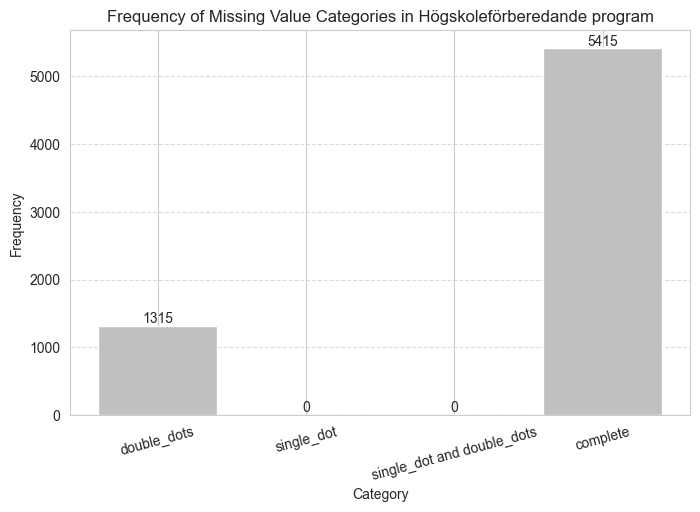

/var/folders/dk/hpy2mtkd7sq6_2c3125100b80000gn/T/ipykernel_14714/4075108272.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_missing['academic_year_numeric'] = df_missing['academic_year'].str[-2:].astype(int)


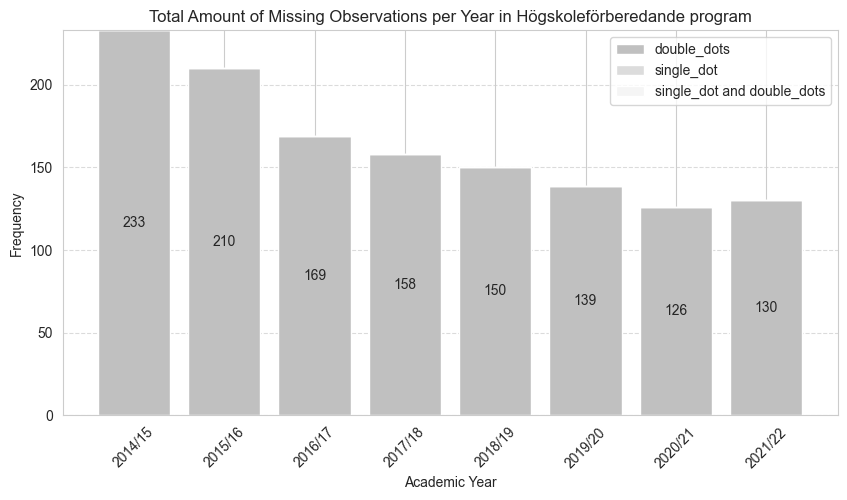

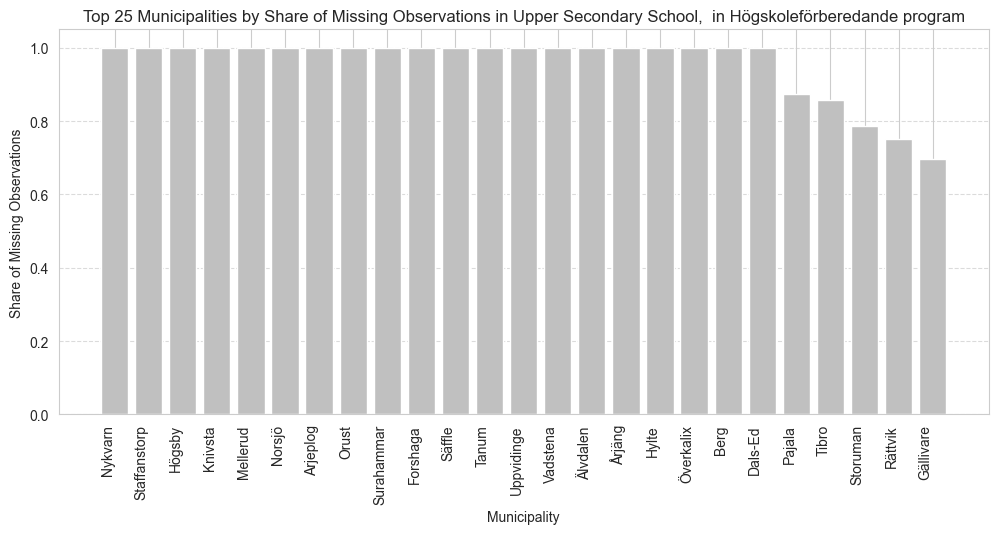

In [26]:
# Step 3 - Analyzing Types of Missing Data

"""
Observera att uppgifter avseende kön, utländsk bakgrund samt föräldrarnas utbildningsnivå dubbelprickas om de baseras på färre än 10 elever.
Då visas två prickar (..) istället för utfall. Om data saknas visas en prick (.)  istället för utfall.
"""

# --- Plot 1: Frequency of Missing Value Categories ---

# Function to classify rows based on presence of '.' and '..'
def classify_missing_rows(row):
    contains_single_dot = (row == '.').any()
    contains_double_dot = (row == '..').any()

    if contains_single_dot and contains_double_dot:
        return "single_dot and double_dots"
    elif contains_double_dot:
        return "double_dots"
    elif contains_single_dot:
        return "single_dot"
    else:
        return "complete"

# Apply classification to the DataFrame
DataFrame_II["missing_data"] = DataFrame_II.apply(classify_missing_rows, axis=1)

# Define all possible category labels to ensure they appear in the plot
all_categories = ["double_dots", "single_dot", "single_dot and double_dots", "complete"]

# Count occurrences of each category and reindex to include all categories
category_counts = DataFrame_II['missing_data'].value_counts().reindex(all_categories, fill_value=0)

# Plot the frequency of each category
plt.figure(figsize=(8, 5))
bars = plt.bar(category_counts.index, category_counts.values, color='silver')

# Add count annotations to each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}', ha='center', va='bottom')

# Formatting
plt.xlabel("Category")
plt.ylabel("Frequency")
plt.title(f"Frequency of Missing Value Categories in {program}")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()

# --- Plot 2: Total Amount of Missing Observations per Year ---

# Function to filter rows that contain missing indicators
def filter_missing_rows(df): 
    return df[df.isin(['double_dots', 'single_dot', 'single_dot and double_dots']).any(axis=1)]

# Apply filtering to obtain only rows with missing data
df_missing = filter_missing_rows(DataFrame_II)

# Optionally, extract a numeric value from the academic_year column for sorting purposes.
# Here we assume academic_year is in a "YYYY/YY" format.
df_missing['academic_year_numeric'] = df_missing['academic_year'].str[-2:].astype(int)

# Group by academic year and missing data category, then count occurrences.
grouped = df_missing.groupby(['academic_year', 'missing_data']).size().unstack(fill_value=0)
grouped = grouped.reindex(sorted(df_missing['academic_year'].unique()))

# Define the order of categories for stacking.
categories_order = ['double_dots', 'single_dot', 'single_dot and double_dots']

# Define colors for each category.
colors = {
    'double_dots': 'silver',
    'single_dot': 'gainsboro',
    'single_dot and double_dots': 'whitesmoke'
}

# Plot the stacked bar chart
fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(grouped))  # Initialize bottom for stacking

# Loop over each category, plotting its segment and adding count annotations.
for cat in categories_order:
    values = grouped.get(cat, pd.Series(0, index=grouped.index))
    bars = ax.bar(grouped.index, values, bottom=bottom, label=cat, color=colors[cat])
    
    # Add text labels to each segment
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[i] + height / 2,
                str(int(height)),
                ha='center',
                va='center',
                fontsize=10
            )
    bottom += values  # Update bottom for next category

# Formatting the plot
ax.set_xlabel("Academic Year")
ax.set_ylabel("Frequency")
ax.set_title(f'Total Amount of Missing Observations per Year in {program}')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

# Display the plot
plt.show()

# --- Plot 3: Frequency of Missing Observations per Municipality ---

# Calculate missing counts per municipality using the "missing_data" column
# (Rows with missing data are those where missing_data is not "complete")
missing_counts = DataFrame_II.loc[DataFrame_II['missing_data'] != 'complete', 'school_municipality'].value_counts()

# Calculate total counts per municipality from the full DataFrame
total_counts = DataFrame_II['school_municipality'].value_counts()

# Compute the share of missing observations per municipality
share_missing = missing_counts / total_counts

# Sort the share values in descending order and select the top 25 municipalities
top25_share_missing = share_missing.sort_values(ascending=False).head(25)

# Plot the share of missing observations per municipality for the top 25
plt.figure(figsize=(12, 5))
plt.bar(top25_share_missing.index, top25_share_missing.values, color='silver')

# Formatting the plot
plt.xlabel("Municipality")
plt.ylabel("Share of Missing Observations")
plt.title(f"Top 25 Municipalities by Share of Missing Observations in Upper Secondary School,  in {program}")
plt.xticks(rotation=90, ha="right")  # Rotate labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

# Dropping column created for plot 1
DataFrame_II.drop('missing_data', axis = 1, inplace=True)

# Deleting from global namespace
del df_missing

In [27]:
# Step 4 -  Final Modification to the Dataframe_II

# Replacing . and .. with np.nan 
DataFrame_II.replace(['.', '..'], np.nan, inplace=True)

# Define the desired column order
column_order = ['school_ID', 'school_municipality', 'municipality_ID', 'type_of_ownership', 'academic_year', 'educational_stage',
                'total_school_students',  'school_size',
                'share_female_students', 'share_foreign_background', 'share_postsecondary_parents']

# Reorder the DataFrame
DataFrame_II = DataFrame_II[column_order]

/var/folders/dk/hpy2mtkd7sq6_2c3125100b80000gn/T/ipykernel_14714/837626943.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  DataFrame_II.replace(['.', '..'], np.nan, inplace=True)


Gymnasieskola - Personalstatistik med lärarlegitimation och behörighet 2014/15 till 2021/22 

"Statistiken avser anställda den 15 oktober valt läsår."

- Höstterminens år används i namnen på excel filerna
- Därav så ändrar vi manuellt till vårterminens år för att matcha korrekt med andra DataFrames
- Antagande att 'Personalstatistik med lärarlegitimation och behörighet' är detsamma på höst- och vårterminen

In [28]:
# Step 1 - Creating Dataframe_III

# Setting the path 
path = r'/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Raw Data/Skolverket Data/gymnasieskola_III'

# Get all Excel files in the folder
all_files = glob.glob(os.path.join(path, "*.xlsx"))

# Sort the files (ascending by default)
all_files.sort()

# Predefined list of years (ensure this list matches the number of files and in the right order of how python reads the folder (ascending or descending))
ACADEMIC_YEAR = ['2014/15', '2015/16', '2016/17','2017/18', '2018/19', '2019/20', '2020/21', '2021/22']

# Defining a function
def read_excel_files(sheet_name):

    """""
    This function reads each excel file from the specified path and sheet, modifies the dataframes, and then creates a concatenated DataFrame

    Parameters:
    - sheet_name: specify which sheet name from the Excel file to read
    """""

    # Create an empty list to store DataFrames
    li = []
    
    # A for loop
    for i, filename in enumerate(all_files):
            
        if i == 0:
            # For the first file, read without skipping rows to extract the header row 
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Extract column names from row index 9, Pandas DataFrame positioning
            column_names = temp_df.iloc[9].tolist()
            # Now read the data, skipping the first 10 rows from the Excel File
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=10)
            # Assign the extracted column names
            df.columns = column_names
        else:
            # For subsequent files, read without skipping rows to locate the matching row
            temp_df = pd.read_excel(filename, sheet_name=sheet_name, header=None)
            # Locate the row number where the column names match
            column_names_row = temp_df.apply(lambda row: row.tolist() == column_names, axis=1).idxmax()
            # Read the data, skipping rows up to the matching row 
            df = pd.read_excel(filename, sheet_name=sheet_name, header=None, skiprows=column_names_row + 1) # adding 1 since Excel start from index/row 1
            # Assign the extracted column names
            df.columns = column_names

        # Add the "läsår_vår" column using the predefined years list
        df["academic_year"] = ACADEMIC_YEAR[i]

        # Add the "skolform" column with the fixed value 'upper secondary school'
        df["educational_stage"] = 'gymnasieskola'

        # Append the DataFrame to the list
        li.append(df)
    
    return pd.concat(li, ignore_index=True)

# Applying the function, with specified sheet name
DataFrame_III = read_excel_files("Samtliga lärare" ) 

In [29]:
# Step 2  - Renaming columns and dropping columns

# Define a list of new column names in the correct order
new_column_names = [
    'school_name',                                            # Column 1 'Skola'
    'school_ID',                                              # Column 2 'Skol-enhetskod'
    'school_municipality',                                    # Column 3 'Skolkommun'
    'municipality_ID',                                        # Column 4 'Kommun-kod'
    'type_of_ownership',                                      # Column 5 'Typ av huvudman'
    'owner',                                                  # Column 6 'Huvudman'
    'owner_orgnr',                                            # Column 7 'Huvudman orgnr'
    'total_fulltime_teachers',                                # Column 8 'Heltidstjänster Totalt antal'
    'total_fulltime_certified_teachers',                      # Column 9 'Heltidstjänster Antal med lärarlegitimation och behörighet'
    'share_fulltime_certified_teachers',                      # Column 10 'Heltidstjänster Andel med lärarlegitimation och behörighet'
    'heltid_förstelärare',                                    # Column 11 'Heltidstjänster Förstelärare'
    'total_active_teachers',                                  # Column 12 'Tjänstgörande lärare Totalt antal '
    'total_active_certified_teachers',                        # Column 13 'Tjänstgörande lärare Antal med lärarlegitimation och behörighet i minst ett ämne'
    'share_active_certified_teachers',                        # Column 14 'Tjänstgörande lärare Andel med lärarlegitimation och behörighet i minst ett ämne'
    'tjänst_förstelärare',                                    # Column 15 'Tjänstgörande lärare Förstelärare '
    'academic_year',                                          # Column 16 'läsår'
    'educational_stage'                                       # Column 17 'skolform'
    ]

# Define a list of columns to drop
columns_to_drop = [
    'school_name',                                            # Column 1 'Skola'
    'owner',                                                  # Column 6 'Huvudman'
    'owner_orgnr',                                            # Column 7 'Huvudman orgnr'
    'heltid_förstelärare',                                    # Column 11 'Heltidstjänster Förstelärare'
    'tjänst_förstelärare',                                    # Column 15 'Tjänstgörande lärare Förstelärare '
    ]

# Define the desired column order
column_order = ['school_ID', 'school_municipality', 'municipality_ID', 'type_of_ownership', 'academic_year', 'educational_stage',
                'total_fulltime_teachers', 'total_fulltime_certified_teachers', 'share_fulltime_certified_teachers',            
                'total_active_teachers', 'total_active_certified_teachers', 'share_active_certified_teachers']  

# Assigning new column names
DataFrame_III.columns = new_column_names 

# Dropping columns which will not be used
DataFrame_III.drop(columns=columns_to_drop, axis=1, inplace=True)

# Reorder the DataFrame
DataFrame_III = DataFrame_III[column_order]

Merging DataFrames

DataFrame_I: Gymnasieskola - Avgångselever, nationella program läsår 2014/15 till 2023/24 

DataFrame_II: Gymnasieskola - Antal elever 2014/15 till 2021/22

DataFrame_III: Gymnasieskola - Personalstatistik med lärarlegitimation och behörighet 2014/15 till 2021/22 

In [30]:
# --- Step 1 Merging DataFrames ---

# https://www.geeksforgeeks.org/different-types-of-joins-in-pandas/
# Using LEFT JOIN
# Gymnasieskola_I <- Gymnasieskola_II  
# Gymnasieskola_I <- Gymnasieskola_III

# Define the join keys (columns that will NOT receive suffixes)
join_keys = ['school_ID', 'school_municipality', 'municipality_ID', 'type_of_ownership', 'academic_year', 'educational_stage']

# Merge the first two DataFrames with an left join and custom suffixes:
DataFrame = pd.merge(
    DataFrame_I,
    DataFrame_II, 
    on = join_keys,
    how = 'left')

# Merge the first two DataFrames with an inner join and custom suffixes:
DataFrame = pd.merge(
    DataFrame,
    DataFrame_III, 
    on = join_keys,
    how = 'left')

# --- Step 2 Preparing for exporting DataFrames ---

# Define common columns to keep in all subsets
common_columns = [
    'school_ID', 'school_municipality', 'municipality_ID', 'type_of_ownership', 'academic_year', 'educational_stage',
    'school_size', 'total_school_students', 'graduating_students', 'graduates_average_grade_points',
    'share_female_students', 'share_foreign_background', 'share_postsecondary_parents', 
    'total_fulltime_teachers', 'total_fulltime_certified_teachers', 'share_fulltime_certified_teachers', 
    'total_active_teachers', 'total_active_certified_teachers', 'share_active_certified_teachers'
]

# Define specific columns for each subject
english_columns = common_columns + ['share_students_A_E_eng', 'share_students_F_eng']
mathematics_columns = common_columns + ['share_students_A_E_ma', 'share_students_F_ma']
swedish_columns = common_columns + ['share_students_A_E_sv', 'share_students_F_sv']

# Create separate DataFrames
gymnasieskola_engelska = DataFrame[english_columns]
gymnasieskola_matematik = DataFrame[mathematics_columns]
gymnasieskola_svenska = DataFrame[swedish_columns]

# --- Step 3 Exporting --- 

# Defining the full path where the Excel file will be saved
path = '/Users/andrescruz/Documents/Handelshögskolan/MSc Economic/Semester 4/5350 Thesis in Economics/Processed Data/gymnasieskola_ämnen.xlsx'

# Exporting all the tables created into one Excel File
with pd.ExcelWriter(path) as writer:
    gymnasieskola_engelska.to_excel(writer, sheet_name='English', index=False)
    gymnasieskola_matematik.to_excel(writer, sheet_name='Mathematics', index=False)
    gymnasieskola_svenska.to_excel(writer, sheet_name='Swedish', index=False)